In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [5]:
import zipfile
import os

# Step 1 - Unzip
with zipfile.ZipFile('train.csv.zip', 'r') as z:
    z.extractall('/content/')

# Step 2 - Check files
print(os.listdir('/content/'))

# Step 3 - Load
import pandas as pd
df = pd.read_csv('/content/train.csv')
print("✅ Data Loaded!")
print("Shape:", df.shape)
df.head()

['.config', 'train.csv.zip', 'train.csv', 'train.csv (1).zip', '.ipynb_checkpoints', 'sample_data']
✅ Data Loaded!
Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nCategories:")
print(df['Category'].value_counts())

Shape: (9800, 18)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Categories:
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64


In [9]:
# Convert dates with correct format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Extract Year and Month
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')

# Drop missing Postal Code rows
df.dropna(subset=['Postal Code'], inplace=True)

print("✅ Data cleaned!")
print("Shape:", df.shape)
print("Years in data:", df['Year'].unique())
df.head()

✅ Data cleaned!
Shape: (9789, 21)
Years in data: [2017 2016 2015 2018]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,Nov
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,Nov
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,Jun
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,Oct
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,Oct


In [10]:
total_sales  = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
avg_order    = df['Sales'].mean()
total_customers = df['Customer ID'].nunique()

print("=" * 45)
print("       📊 KEY PERFORMANCE INDICATORS")
print("=" * 45)
print(f"  💰 Total Sales      : ${total_sales:,.2f}")
print(f"  📦 Total Orders     : {total_orders}")
print(f"  👥 Total Customers  : {total_customers}")
print(f"  🛒 Avg Order Value  : ${avg_order:,.2f}")
print("=" * 45)

       📊 KEY PERFORMANCE INDICATORS
  💰 Total Sales      : $2,252,607.41
  📦 Total Orders     : 4916
  👥 Total Customers  : 793
  🛒 Avg Order Value  : $230.12


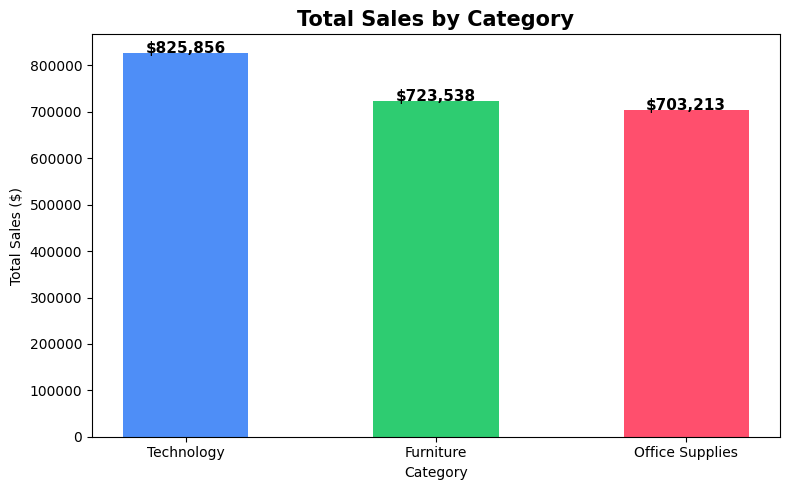

✅ Chart 1 done!


In [11]:
plt.figure(figsize=(8,5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

bars = plt.bar(category_sales.index, category_sales.values,
               color=['#4e8ef7', '#2ecc71', '#ff4f6d'],
               edgecolor='none', width=0.5)

for bar, val in zip(bars, category_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000,
             f'${val:,.0f}', ha='center',
             fontsize=11, fontweight='bold')

plt.title('Total Sales by Category', fontsize=15, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Category')
plt.tight_layout()
plt.savefig('sales_by_category.png', bbox_inches='tight')
plt.show()
print("✅ Chart 1 done!")

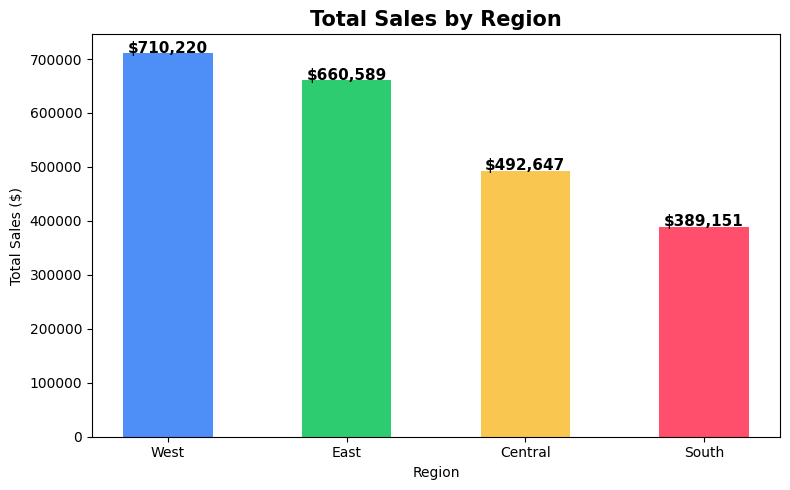

✅ Chart 2 done!


In [12]:
plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

bars = plt.bar(region_sales.index, region_sales.values,
               color=['#4e8ef7', '#2ecc71', '#f9c74f', '#ff4f6d'],
               edgecolor='none', width=0.5)

for bar, val in zip(bars, region_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000,
             f'${val:,.0f}', ha='center',
             fontsize=11, fontweight='bold')

plt.title('Total Sales by Region', fontsize=15, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Region')
plt.tight_layout()
plt.savefig('sales_by_region.png', bbox_inches='tight')
plt.show()
print("✅ Chart 2 done!")

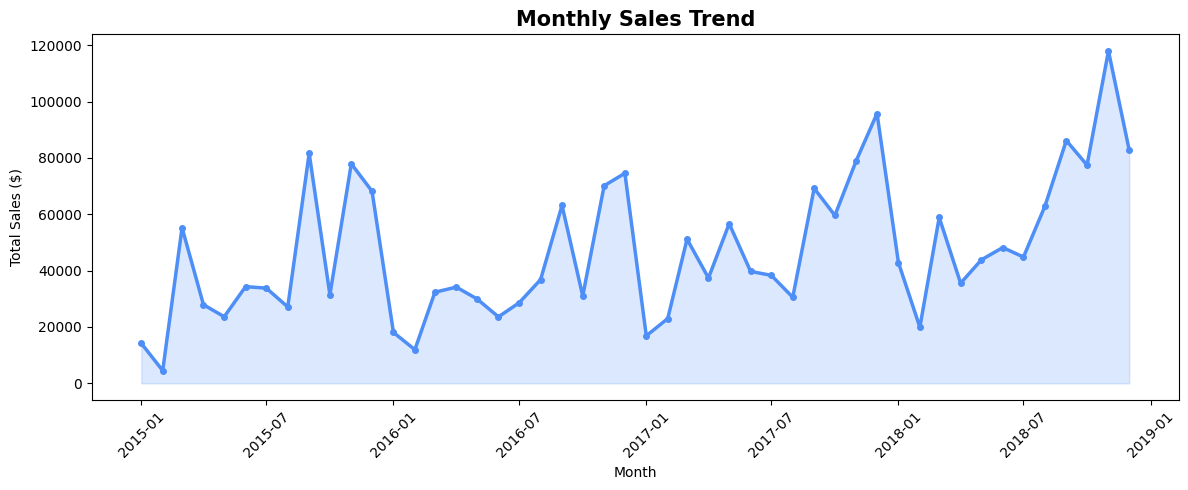

✅ Chart 3 done!


In [13]:
plt.figure(figsize=(12,5))
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales[['Year','Month']].assign(day=1))
monthly_sales = monthly_sales.sort_values('Date')

plt.plot(monthly_sales['Date'], monthly_sales['Sales'],
         color='#4e8ef7', linewidth=2.5,
         marker='o', markersize=4)
plt.fill_between(monthly_sales['Date'],
                 monthly_sales['Sales'],
                 alpha=0.2, color='#4e8ef7')

plt.title('Monthly Sales Trend', fontsize=15, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', bbox_inches='tight')
plt.show()
print("✅ Chart 3 done!")

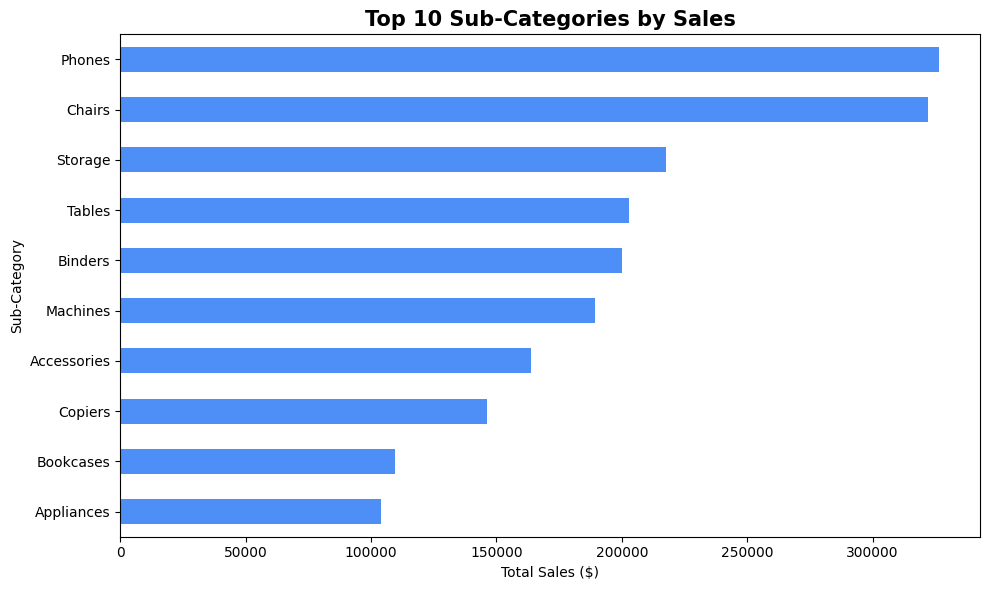

✅ Chart 4 done!


In [14]:
plt.figure(figsize=(10,6))
top_sub = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).sort_values()

top_sub.plot(kind='barh', color='#4e8ef7', edgecolor='none')

plt.title('Top 10 Sub-Categories by Sales',
          fontsize=15, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.savefig('top_subcategories.png', bbox_inches='tight')
plt.show()
print("✅ Chart 4 done!")

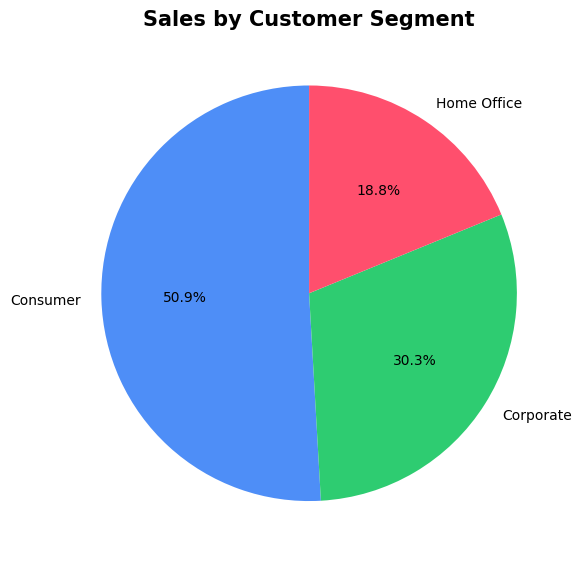

✅ Chart 5 done!


In [15]:
plt.figure(figsize=(6,6))
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%',
                   colors=['#4e8ef7', '#2ecc71', '#ff4f6d'],
                   startangle=90)

plt.title('Sales by Customer Segment',
          fontsize=15, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('sales_by_segment.png', bbox_inches='tight')
plt.show()
print("✅ Chart 5 done!")

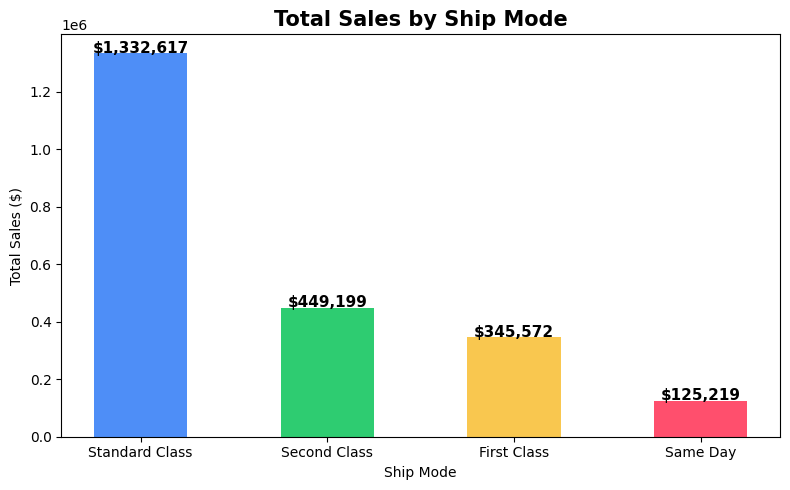

✅ Chart 6 done!


In [16]:
plt.figure(figsize=(8,5))
ship_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

bars = plt.bar(ship_sales.index, ship_sales.values,
               color=['#4e8ef7', '#2ecc71', '#f9c74f', '#ff4f6d'],
               edgecolor='none', width=0.5)

for bar, val in zip(bars, ship_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000,
             f'${val:,.0f}', ha='center',
             fontsize=11, fontweight='bold')

plt.title('Total Sales by Ship Mode',
          fontsize=15, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Ship Mode')
plt.tight_layout()
plt.savefig('sales_by_shipmode.png', bbox_inches='tight')
plt.show()
print("✅ Chart 6 done!")

In [17]:
print("=" * 50)
print("       📊 FINAL BUSINESS INSIGHTS")
print("=" * 50)

best_cat = df.groupby('Category')['Sales'].sum().idxmax()
print(f"\n🏆 Best Selling Category  : {best_cat}")

best_region = df.groupby('Region')['Sales'].sum().idxmax()
print(f"🌍 Best Region            : {best_region}")

best_sub = df.groupby('Sub-Category')['Sales'].sum().idxmax()
print(f"📦 Best Sub-Category      : {best_sub}")

best_segment = df.groupby('Segment')['Sales'].sum().idxmax()
print(f"👥 Best Customer Segment  : {best_segment}")

best_year = df.groupby('Year')['Sales'].sum().idxmax()
print(f"📅 Best Sales Year        : {best_year}")

best_ship = df.groupby('Ship Mode')['Sales'].sum().idxmax()
print(f"🚚 Most Used Ship Mode    : {best_ship}")

print("\n📌 Key Business Recommendations:")
print("  ✅ Focus more on Technology category")
print("  ✅ Invest more in West region")
print("  ✅ Target Consumer segment more")
print("  ✅ Sales peak in November-December")
print("=" * 50)

       📊 FINAL BUSINESS INSIGHTS

🏆 Best Selling Category  : Technology
🌍 Best Region            : West
📦 Best Sub-Category      : Phones
👥 Best Customer Segment  : Consumer
📅 Best Sales Year        : 2018
🚚 Most Used Ship Mode    : Standard Class

📌 Key Business Recommendations:
  ✅ Focus more on Technology category
  ✅ Invest more in West region
  ✅ Target Consumer segment more
  ✅ Sales peak in November-December
